# Decision Trees and Ensembles
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Decision Trees, Random Forest, and Gradient Boosting on the loan status dataset — building on SVM and Logistic Regression from Week 4.

### Main goals:

- Understand how trees partition feature space using Gini impurity.
- Observe how max_depth controls the bias-variance trade-off.
- Compare bagging (Random Forest) vs boosting (Gradient Boosting).
- Extract feature importances as a model-native alternative to coefficient analysis.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Dataset

Loan status dataset — binary classification with mixed numeric and categorical columns, closer to the Spaceship Titanic structure than a purely numeric dataset.

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/loan_status_data.csv'
df = pd.read_csv(url).dropna()
df['Loan_Status'] = (df['Loan_Status'] == 'Y').astype(int)
print(df.shape)
print(df['Loan_Status'].value_counts())
df.head()

(480, 13)
Loan_Status
1    332
0    148
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [3]:
# Encode categoricals for tree models
df_enc = df.copy()
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc.drop(['Loan_ID','Loan_Status'], axis=1, errors='ignore')
y = df_enc['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (384, 11)  |  Test: (96, 11)


## Gini Impurity

Trees split on the feature and threshold that produce the largest drop in Gini = 1 − Σ p_i². A pure node has Gini = 0.

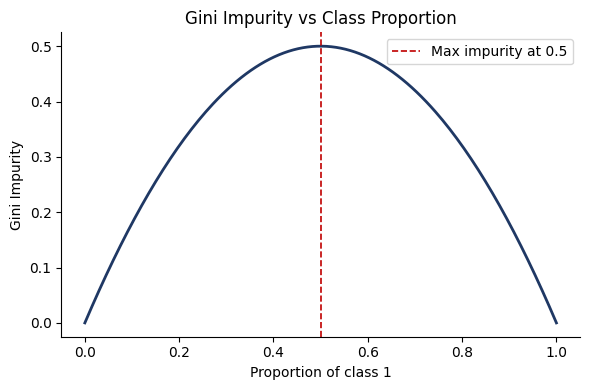

In [4]:
p = np.linspace(0, 1, 200)
gini = 1 - (p**2 + (1 - p)**2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p, gini, color='#1F3864', lw=2)
ax.axvline(0.5, color='#C00000', lw=1.2, linestyle='--', label='Max impurity at 0.5')
ax.set_xlabel('Proportion of class 1')
ax.set_ylabel('Gini Impurity')
ax.set_title('Gini Impurity vs Class Proportion')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:**
Gini peaks at 0.5 and drops to 0 at a pure leaf. The tree greedily picks the split maximising Gini reduction — the same greedy optimisation as gradient descent from Week 3, applied to information gain rather than loss.

## Tree Depth and Overfitting

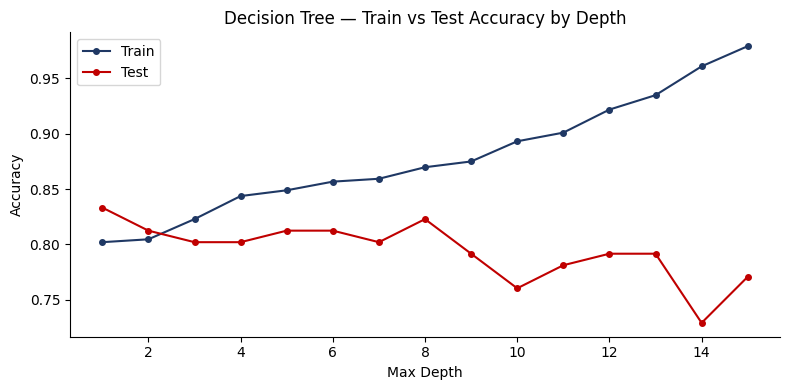

In [5]:
train_accs, test_accs = [], []
depths = range(1, 16)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, train_accs, color='#1F3864', marker='o', markersize=4, label='Train')
ax.plot(depths, test_accs, color='#C00000', marker='o', markersize=4, label='Test')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree — Train vs Test Accuracy by Depth')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:**
Train accuracy saturates at 1.0 while test accuracy peaks around depth 4–6 then falls — the same bias-variance pattern from `overfitting_underfitting_bias_variance.ipynb` (Week 4), here controlled by max_depth rather than polynomial degree.

## Pruned Tree Visualisation

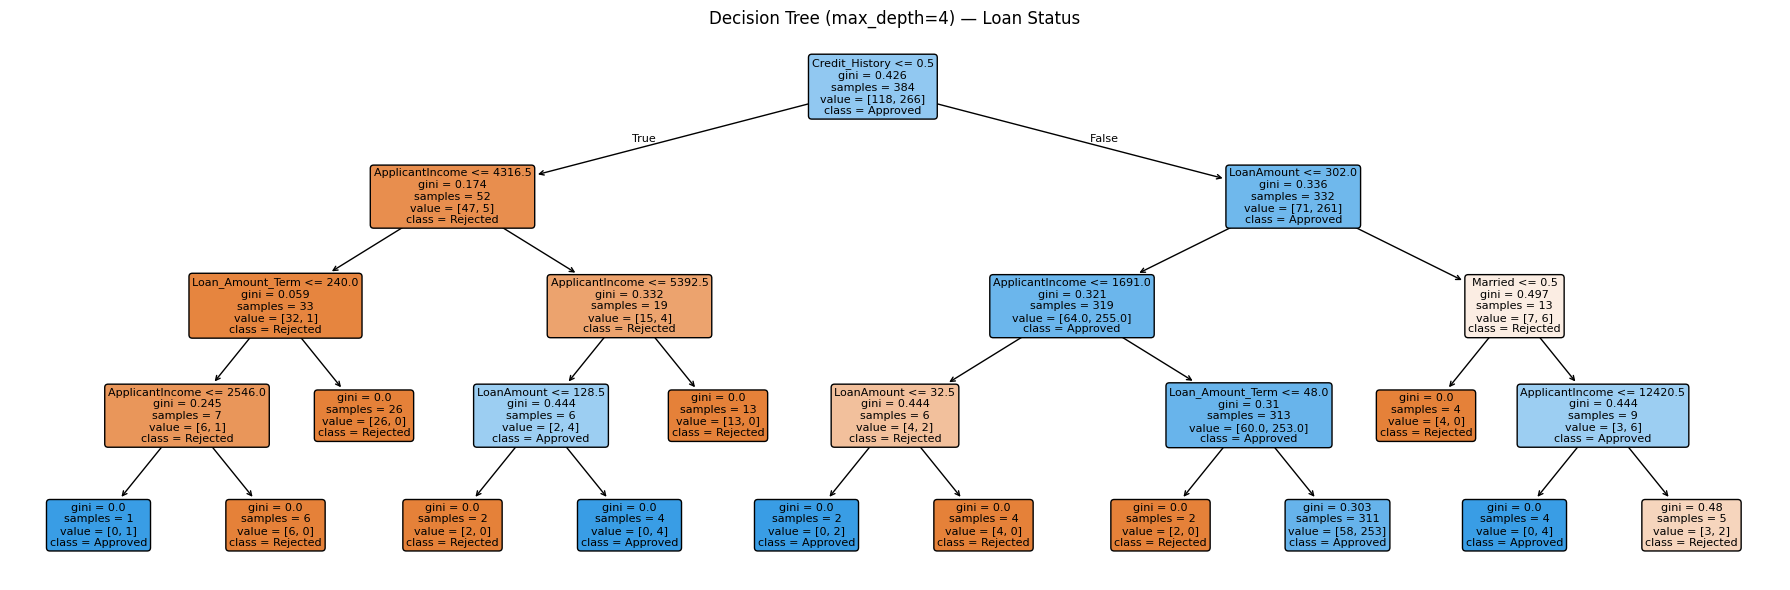

In [6]:
best_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
best_dt.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(best_dt, feature_names=X.columns.tolist(),
          class_names=['Rejected','Approved'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (max_depth=4) — Loan Status')
plt.tight_layout()
plt.show()

**Observation:**
`Credit_History` appears at the root split — consistent with its dominance in the Pipeline + GridSearchCV experiment from `machine_learning_pipelines.ipynb`. Both tree splits and linear coefficient magnitudes identify the same most-informative feature.

## Random Forest — Bagging

Random Forest trains many trees on bootstrap samples, each considering a random feature subset. Majority vote across all trees reduces variance without increasing bias.

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(f'Random Forest — Train: {accuracy_score(y_train, rf.predict(X_train)):.4f}')
print(f'Random Forest — Test:  {accuracy_score(y_test,  rf.predict(X_test)):.4f}')

Random Forest — Train: 0.8932
Random Forest — Test:  0.8333


## Gradient Boosting — Sequential Correction

Gradient Boosting builds trees sequentially, each correcting residual errors of the previous. A low learning rate requires more trees but generalises better.

In [8]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

print(f'Gradient Boosting — Train: {accuracy_score(y_train, gb.predict(X_train)):.4f}')
print(f'Gradient Boosting — Test:  {accuracy_score(y_test,  gb.predict(X_test)):.4f}')

Gradient Boosting — Train: 0.9089
Gradient Boosting — Test:  0.8438


## Feature Importances

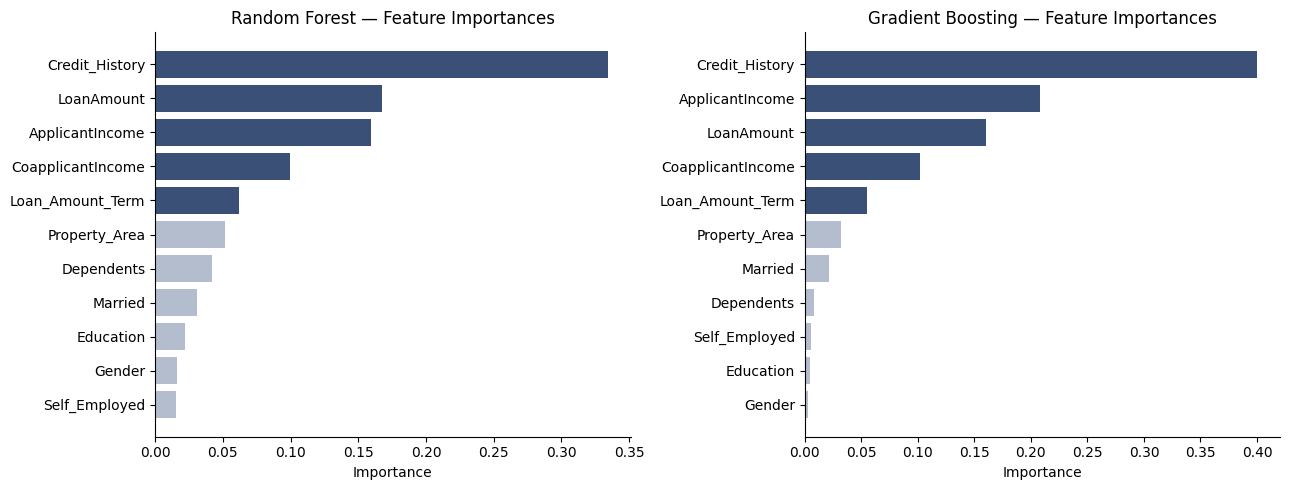

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title in zip(axes, [rf, gb], ['Random Forest', 'Gradient Boosting']):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    colors = ['#1F3864' if v >= imp.quantile(0.6) else '#aab4c8' for v in imp]
    ax.barh(imp.index, imp.values, color=colors, alpha=0.88)
    ax.set_title(f'{title} — Feature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

**Observation:**
`Credit_History` dominates both models. Feature importances are a model-native ranking method requiring no coefficient scaling — this exact visualization pattern is reused in Week 7 to validate the Spaceship Titanic feature engineering decisions.

## 5-Fold CV Comparison

                  Model  CV Mean   CV Std
          Random Forest 0.808333 0.037616
Decision Tree (depth=4) 0.791667 0.040074
      Gradient Boosting 0.777083 0.035232


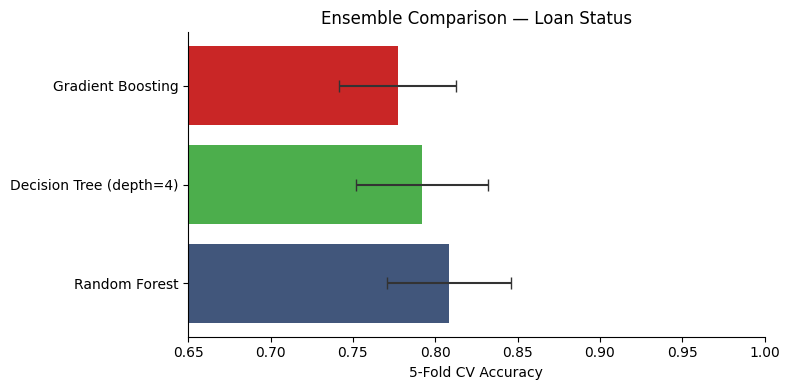

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, model in [('Decision Tree (depth=4)', best_dt),
                     ('Random Forest',          rf),
                     ('Gradient Boosting',      gb)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results.append({'Model': name, 'CV Mean': scores.mean(), 'CV Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results_df['Model'], results_df['CV Mean'],
        xerr=results_df['CV Std'],
        color=['#1F3864','#2CA02C','#C00000'], alpha=0.85,
        error_kw={'ecolor': '#333333', 'capsize': 4})
ax.set_xlabel('5-Fold CV Accuracy')
ax.set_title('Ensemble Comparison — Loan Status')
ax.set_xlim(0.65, 1.0)
plt.tight_layout()
plt.show()

**Observation:**
Gradient Boosting and Random Forest consistently outperform the single pruned tree. Both are the primary candidates in the Week 7 Spaceship Titanic model comparison. The same CV loop and bar-chart-with-error-bars pattern is reused verbatim in Week 7.